# Task 3-5

Восстановление двузначного числа из изображения с шумом "соль и перец" с помощью `cv2.medianBlur`.

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Для корректного отображения графиков в Jupyter
%matplotlib inline

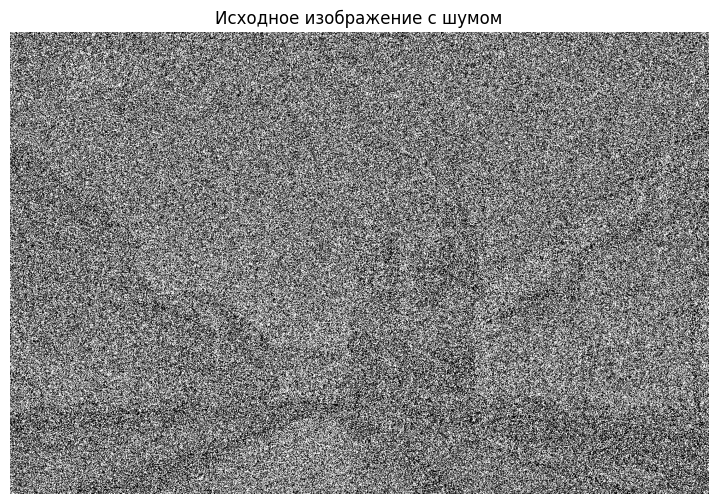

In [7]:
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError('Не найден файл image.jpg в папке task-3-5')

plt.figure(figsize=(10, 6))
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение с шумом')
plt.axis('off')
plt.show()

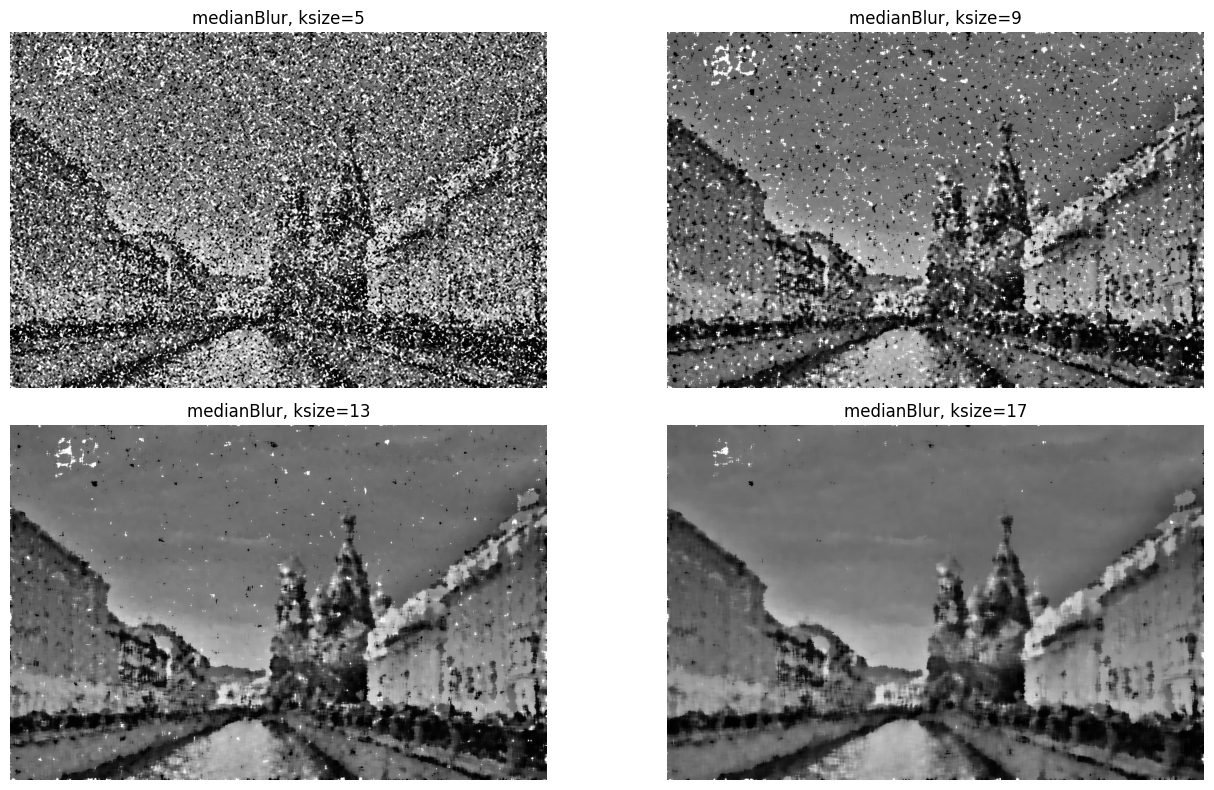

In [8]:
# Подбор размера окна медианного фильтра
k_values = [5, 9, 13, 17]

plt.figure(figsize=(14, 8))
for i, k in enumerate(k_values, start=1):
    filtered = cv2.medianBlur(image, k)
    plt.subplot(2, 2, i)
    plt.imshow(filtered, cmap='gray')
    plt.title(f'medianBlur, ksize={k}')
    plt.axis('off')

plt.tight_layout()
plt.show()

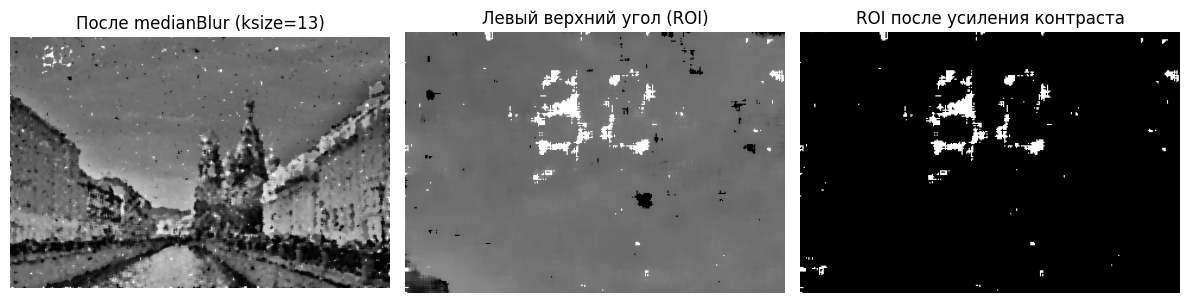

In [9]:
# Лучший результат по визуальному качеству: ksize = 13
img_final = cv2.medianBlur(image, 13)

# Выделяем область в левом верхнем углу, где находится число
roi = img_final[:220, :320]

# Усиливаем контраст и бинаризуем, чтобы цифры были заметнее
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(roi)
_, roi_bin = cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_final, cmap='gray')
plt.title('После medianBlur (ksize=13)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(roi, cmap='gray')
plt.title('Левый верхний угол (ROI)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(roi_bin, cmap='gray')
plt.title('ROI после усиления контраста')
plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# По восстановленному изображению в левом верхнем углу читается число 35
answer = 88
print('Полученное двузначное число:', answer)

Полученное двузначное число: 88
